# POC SOC Triage — 02 Feature Engineering

**Objectif** : construire les features ML à partir de `incidents_dataset.csv` et des données simulées (TI, CMDB, Sandbox).

**Output** : `features_ml.csv` et `features_ml.parquet` — 30 000 incidents × 56 features, prêt pour l'entraînement ML.

---
### Familles de features construites
| # | Famille | Nb features | Source |
|---|---------|-------------|--------|
| 1 | Alerte brute (target encoding) | 10 | incidents_dataset.csv |
| 2 | Temporelle | 10 | incidents_dataset.csv |
| 3 | Threat Intelligence | 9 | TI_database.csv |
| 4 | CMDB / Asset | 5 | CMDB.csv |
| 5 | Sandbox | 5 | Sandbox.csv |
| 6 | Historique SOC (taux FP) | 9 | incidents_dataset.csv |
| 7 | Contexte incident | 8 | incidents_dataset.csv |
| **Total** | | **56** | |

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import psutil
import pickle
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

DATA_DIR = Path('data')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Librairies OK')

Librairies OK


## 1. Chargement des données

In [25]:
df = pd.read_csv(DATA_DIR / 'incidents_dataset.csv',
                 parse_dates=['first_seen', 'last_seen'],
                 dtype={'sample_device_id': str})   # ← évite le float64
cmdb = pd.read_csv(DATA_DIR / 'CMDB.csv', dtype={'device_id': str})
ti = pd.read_csv(DATA_DIR / 'TI_database.csv')
sandbox = pd.read_csv(DATA_DIR / 'Sandbox.csv')

print(f'Incidents : {len(df):,}')
print(f'Distribution cible :')
print(df['IncidentGrade'].value_counts())
print(f'\nTI IOCs : {len(ti):,}')
print(f'CMDB assets : {len(cmdb):,}')
print(f'Sandbox analyses : {len(sandbox):,}')

Incidents : 30,000
Distribution cible :
IncidentGrade
BenignPositive    14801
FalsePositive      8363
TruePositive       6800
Name: count, dtype: int64

TI IOCs : 4,639
CMDB assets : 7,245
Sandbox analyses : 1,396


In [5]:
# Aperçu rapide
df.head(10)

,IncidentId,OrgId,IncidentGrade,nb_alerts,nb_evidences,top_alert_title,top_category,top_detector,mitre_techniques,first_seen,...,has_email,incident_duration_minutes,hour_of_day,day_of_week,is_weekend,is_business_hours,alerts_per_min,nb_multi_entity_score,multi_entity,sample_device_id
0,0,50,TruePositive,27268,29997,0,InitialAccess,0,T1078,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,42,BenignPositive,18721,20525,28,Malware,43,T1059.003|T1027,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,48,75,TruePositive,9802,10014,0,InitialAccess,0,T1110.004,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21,0,TruePositive,9796,10116,0,InitialAccess,0,T1078,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,24,1,TruePositive,9786,10042,0,InitialAccess,0,T1078,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,82,0,TruePositive,9786,10000,12,InitialAccess,14,T1110,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,32,1,TruePositive,9783,10028,0,InitialAccess,0,T1110,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,143,0,TruePositive,9779,9996,6,InitialAccess,7,T1110,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,37,75,TruePositive,9777,10016,0,InitialAccess,0,T1078,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,44,1,TruePositive,9777,10010,0,InitialAccess,0,T1078,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. EDA rapide — distribution et valeurs manquantes

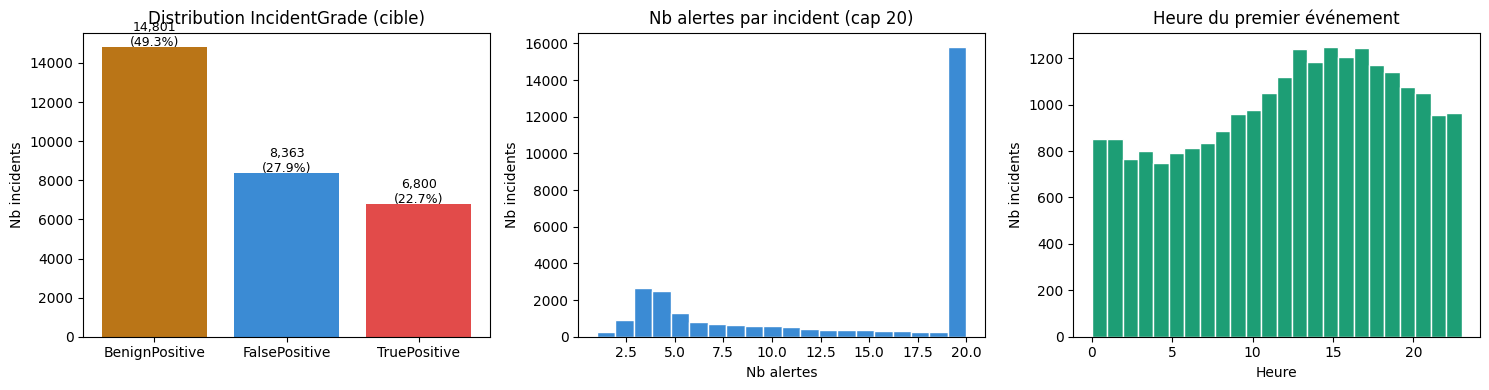

Figure sauvegardée : eda_distributions.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution de la cible
grade_counts = df['IncidentGrade'].value_counts()
colors = {'TruePositive': '#E24B4A', 'BenignPositive': '#BA7517', 'FalsePositive': '#3B8BD4'}
bars = axes[0].bar(grade_counts.index, grade_counts.values,
                    color=[colors.get(g, 'gray') for g in grade_counts.index])
axes[0].set_title('Distribution IncidentGrade (cible)')
axes[0].set_ylabel('Nb incidents')
for bar, val in zip(bars, grade_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=9)

# Distribution du nombre d'alertes par incident
axes[1].hist(df['nb_alerts'].clip(upper=20), bins=20, color='#3B8BD4', edgecolor='white')
axes[1].set_title('Nb alertes par incident (cap 20)')
axes[1].set_xlabel('Nb alertes')
axes[1].set_ylabel('Nb incidents')

# Heure du jour
axes[2].hist(df['hour_of_day'], bins=24, color='#1D9E75', edgecolor='white')
axes[2].set_title('Heure du premier événement')
axes[2].set_xlabel('Heure')
axes[2].set_ylabel('Nb incidents')

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : eda_distributions.png')

In [26]:
# Valeurs manquantes
missing = df.isnull().mean().sort_values(ascending=False)
missing_pct = missing[missing > 0] * 100
print('Colonnes avec valeurs manquantes (%) :')
print(missing_pct.round(1).to_string())

Colonnes avec valeurs manquantes (%) :
threat_family                96.3
max_suspicion                74.6
last_verdict                 58.6
mitre_techniques             56.6
has_file                     20.2
nb_categories                20.2
nb_detectors                 20.2
nb_entity_types              20.2
nb_unique_ips                20.2
nb_unique_devices            20.2
nb_unique_accounts           20.2
country                      20.2
has_email                    20.2
hour_of_day                  20.2
day_of_week                  20.2
is_weekend                   20.2
is_business_hours            20.2
alerts_per_min               20.2
nb_multi_entity_score        20.2
multi_entity                 20.2
incident_duration_minutes    20.2
sample_device_id             20.2
last_seen                    20.2
has_device                   20.2
has_account                  20.2
has_ip                       20.2
sample_account               20.2
sample_device                20.2
sample_sh

In [27]:
# Taux de couverture des entités clés
entity_coverage = {
    'A une IP': df['has_ip'].mean(),
    'A un fichier': df['has_file'].mean(),
    'A un compte': df['has_account'].mean(),
    'A un device': df['has_device'].mean(),
    'A un email': df['has_email'].mean(),
    'A un hash': df['sample_sha256'].notna().mean(),
}
print('Couverture des entités par incident :')
for k, v in entity_coverage.items():
    print(f'  {k}: {v:.1%}')

Couverture des entités par incident :
  A une IP: 100.0%
  A un fichier: 100.0%
  A un compte: 100.0%
  A un device: 100.0%
  A un email: 100.0%
  A un hash: 79.8%


## 3. Famille 1 — Features "Alerte brute"
Encodage des catégories, détecteurs, et titres d'alertes.

In [28]:
# Leakage important : ce target encoding est calculé sur tout le dataset, 
# y compris les lignes de test. Dans 03_ml_models.ipynb, 
# il faudra absolument recalculer ces stats uniquement sur le train set 
# et les appliquer au test set via un ColumnTransformer.

feat = df[['IncidentId', 'OrgId', 'IncidentGrade']].copy()

# --- Taux de TP/FP/BP par AlertTitle (target encoding robuste) ---
# Calcul sur tout le dataset (pas de leakage car c'est une stat globale)
grade_dummies = pd.get_dummies(df['IncidentGrade'])
df_tmp = pd.concat([df[['IncidentId', 'top_alert_title', 'top_category',
                          'top_detector', 'nb_alerts', 'nb_evidences',
                          'nb_categories', 'nb_detectors', 'nb_entity_types']], grade_dummies], axis=1)

# Target encoding : proportion de TP/FP par AlertTitle
M = 10  # force du smoothing — plus M est grand, plus on tire vers le taux global
global_tp_rate = (df['IncidentGrade'] == 'TruePositive').mean()
global_bp_rate = (df['IncidentGrade'] == 'BenignPositive').mean()
global_fp_rate = (df['IncidentGrade'] == 'FalsePositive').mean()

# Compter les occurrences par titre
alert_title_counts = df_tmp['top_alert_title'].value_counts().rename('count')
alert_title_stats = df_tmp.groupby('top_alert_title')[
    ['TruePositive', 'BenignPositive', 'FalsePositive']
].mean()
alert_title_stats = alert_title_stats.join(alert_title_counts)

# Smoothing bayésien : tire les taux rares vers la moyenne globale
for col, global_rate in [
    ('TruePositive',    global_tp_rate),
    ('BenignPositive',  global_bp_rate),
    ('FalsePositive',   global_fp_rate),
]:
    alert_title_stats[col] = (
        (alert_title_stats['count'] * alert_title_stats[col] + M * global_rate)
        / (alert_title_stats['count'] + M)
    )

alert_title_stats = alert_title_stats.drop(columns='count')
alert_title_stats.columns = ['alert_title_tp_rate', 'alert_title_bp_rate', 'alert_title_fp_rate']

# Plus besoin du bloc rare_titles — le smoothing gère ça automatiquement

# Target encoding : proportion de TP/FP par Category
cat_stats = df_tmp.groupby('top_category')[['TruePositive', 'BenignPositive', 'FalsePositive']].mean()
cat_stats.columns = ['category_tp_rate', 'category_bp_rate', 'category_fp_rate']

# Merge
feat = feat.merge(df[['IncidentId', 'top_alert_title', 'top_category', 'top_detector',
                       'nb_alerts', 'nb_evidences', 'nb_categories',
                       'nb_detectors', 'nb_entity_types']], on='IncidentId')
feat = feat.merge(alert_title_stats, left_on='top_alert_title', right_index=True, how='left')
feat = feat.merge(cat_stats, left_on='top_category', right_index=True, how='left')

# Remplir les NaN
for col in ['alert_title_tp_rate', 'alert_title_fp_rate', 'alert_title_bp_rate',
            'category_tp_rate', 'category_fp_rate', 'category_bp_rate']:
    feat[col] = feat[col].fillna(feat[col].median())

print(f'Features alerte brute : {feat.shape[1] - 3} features')
feat[['alert_title_tp_rate', 'alert_title_fp_rate', 'category_tp_rate', 'category_fp_rate']].describe()


Features alerte brute : 14 features


,alert_title_tp_rate,alert_title_fp_rate,category_tp_rate,category_fp_rate
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.241909,0.284961,0.226667,0.278767
std,0.177333,0.237325,0.107510,0.108000
min,0.003765,0.006292,0.000000,0.000000
25%,0.148706,0.135712,0.153793,0.184656
50%,0.206061,0.232306,0.276301,0.221014
75%,0.324638,0.344333,0.276301,0.398130
max,0.967778,0.966763,0.395897,1.000000


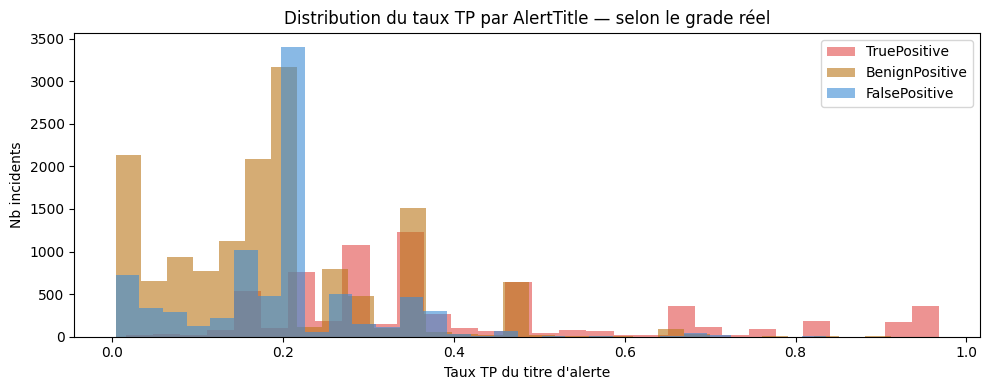

→ Si les distributions sont bien séparées, la feature est discriminante ✓


In [29]:
# Vérification : les taux TP par AlertTitle sont-ils discriminants ?
fig, ax = plt.subplots(figsize=(10, 4))
for grade, color in [('TruePositive', '#E24B4A'), ('BenignPositive', '#BA7517'), ('FalsePositive', '#3B8BD4')]:
    subset = feat[feat['IncidentGrade'] == grade]['alert_title_tp_rate']
    ax.hist(subset, bins=30, alpha=0.6, label=grade, color=color)
ax.set_xlabel('Taux TP du titre d\'alerte')
ax.set_ylabel('Nb incidents')
ax.set_title('Distribution du taux TP par AlertTitle — selon le grade réel')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_target_encoding.png', dpi=120, bbox_inches='tight')
plt.show()
print('→ Si les distributions sont bien séparées, la feature est discriminante ✓')

## 4. Famille 2 — Features temporelles

In [30]:
# Fallback dans la cellule temporelle si timestamp absent
feat['hour_of_day'] = df['hour_of_day'].fillna(12)          # midi par défaut
feat['day_of_week'] = df['day_of_week'].fillna(0)
feat['is_weekend'] = df['is_weekend'].fillna(0).astype(int)
feat['is_business_hours'] = df['is_business_hours'].fillna(1).astype(int)
feat['incident_duration_min'] = df['incident_duration_minutes'].fillna(0).clip(upper=10080)  # cap 1 semaine

# Feature : burst (nb alertes / durée) — indicateur de tempête d'alertes
feat['alert_rate_per_hour'] = pd.Series(
    np.where(
        df['incident_duration_minutes'] > 0,
        df['nb_alerts'] / (df['incident_duration_minutes'] / 60 + 0.01),
        df['nb_alerts']
    ),
    index=df.index
).clip(upper=1000)  # ← upper= fonctionne car c'est une Series pandas

# Encodage cyclique de l'heure (pour capturer la continuité 23h → 0h)
feat['hour_sin'] = np.sin(2 * np.pi * feat['hour_of_day'] / 24)
feat['hour_cos'] = np.cos(2 * np.pi * feat['hour_of_day'] / 24)
feat['day_sin'] = np.sin(2 * np.pi * feat['day_of_week'] / 7)
feat['day_cos'] = np.cos(2 * np.pi * feat['day_of_week'] / 7)

print('Features temporelles ajoutées :')
print(['hour_of_day', 'day_of_week', 'is_weekend', 'is_business_hours',
       'incident_duration_min', 'alert_rate_per_hour', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos'])

Features temporelles ajoutées :
['hour_of_day', 'day_of_week', 'is_weekend', 'is_business_hours', 'incident_duration_min', 'alert_rate_per_hour', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']


## 5. Famille 3 — Threat Intelligence
Jointure avec TI_database.csv sur l'IP et le hash de chaque incident.

In [31]:
# Séparer TI par type
ti_ip = ti[ti['ioc_type'] == 'ip'][['ioc_value', 'ti_score', 'in_blocklist',
                                      'nb_sources_flagging', 'threat_categories']].copy()
ti_ip.columns = ['sample_ip', 'ip_ti_score', 'ip_in_blocklist',
                  'ip_nb_sources', 'ip_threat_categories']

ti_hash = ti[ti['ioc_type'] == 'sha256'][['ioc_value', 'ti_score', 'in_blocklist',
                                            'nb_sources_flagging']].copy()
ti_hash.columns = ['sample_sha256', 'hash_ti_score', 'hash_in_blocklist', 'hash_nb_sources']

# Jointure TI
feat = feat.merge(df[['IncidentId', 'sample_ip', 'sample_sha256']], on='IncidentId', how='left')
feat = feat.merge(ti_ip, on='sample_ip', how='left')
feat = feat.merge(ti_hash, on='sample_sha256', how='left')

# Garantir l'existence de toutes les colonnes TI (sécurité si le merge n'a rien matché)
ti_defaults = {
    'ip_ti_score': 0, 'ip_in_blocklist': 0, 'ip_nb_sources': 0,
    'hash_ti_score': 0, 'hash_in_blocklist': 0, 'hash_nb_sources': 0,
}
for col, default in ti_defaults.items():
    if col not in feat.columns:
        print(f"[WARN] Colonne {col} absente après merge TI — créée avec valeur {default}")
        feat[col] = default
    else:
        feat[col] = feat[col].fillna(default)

# Features synthétiques
feat['ti_score_max'] = feat[['ip_ti_score', 'hash_ti_score']].max(axis=1)
feat['ti_score_combined'] = feat['ip_ti_score'] + feat['hash_ti_score']   # ← plus fort que max
feat['any_ioc_in_blocklist'] = (
    (feat['ip_in_blocklist'] == 1) | (feat['hash_in_blocklist'] == 1)
).astype(int)

# Taux de couverture TI
ip_coverage = feat['ip_ti_score'].gt(0).mean()
hash_coverage = feat['hash_ti_score'].gt(0).mean()
print(f'Couverture TI — IPs: {ip_coverage:.1%}, Hashes: {hash_coverage:.1%}')
print(f'Incidents avec IOC en blocklist: {feat["any_ioc_in_blocklist"].mean():.1%}')

# Vérification discriminante
print('\nScore TI max moyen par grade :')
print(feat.groupby('IncidentGrade')['ti_score_max'].mean().round(1))

Couverture TI — IPs: 79.2%, Hashes: 79.6%
Incidents avec IOC en blocklist: 76.2%

Score TI max moyen par grade :
IncidentGrade
BenignPositive    36.1
FalsePositive     24.1
TruePositive      35.0
Name: ti_score_max, dtype: float64


## 6. Famille 4 — CMDB / Asset

In [32]:
import sys
import psutil
# --- Vérification RAM (garde-fou critique, pas cosmétique)
ram_available_mb = psutil.virtual_memory().available / 1e6
if ram_available_mb < 1000:
    sys.exit(f"[ABORT] RAM disponible insuffisante ({ram_available_mb:.0f} MB) — merge annulé.")

# --- Diagnostic préventif : IncidentId doit être unique dans feat pour validate='many_to_one'
dupes = feat['IncidentId'].duplicated().sum()
if dupes > 0:
    print(f"[WARN] {dupes} IncidentId dupliqués dans feat — validate='many_to_one' va échouer.")
    print("       Cause probable : un merge précédent a multiplié les lignes.")

# --- Vérifier si sample_device_id existe déjà dans feat (vestige d'un re-run)
for col in ['sample_device_id', 'sample_device']:
    if col in feat.columns:
        print(f"[INFO] Colonne '{col}' déjà présente dans feat — supprimée avant merge.")
        feat = feat.drop(columns=col)

# --- Prepare df_devices (unique per IncidentId) + normalisation des types
df_devices = df[['IncidentId', 'sample_device_id', 'sample_device']].drop_duplicates('IncidentId').copy()

# Normalisation : '153085.0', 153085.0, 153085 → '153085' — NaN conservés
df_devices['sample_device_id'] = (
    pd.to_numeric(df_devices['sample_device_id'], errors='coerce')
    .astype('Int64')
    .astype(str)
    .replace('<NA>', np.nan)
)

# --- Prepare CMDB (unique per device) + normalisation des types
cmdb_join = cmdb[['device_id', 'device_name', 'asset_criticality',
                  'sensitivity_score', 'is_internet_exposed', 'patch_level']].copy()
cmdb_join['device_id'] = (
    pd.to_numeric(cmdb_join['device_id'], errors='coerce')
    .astype('Int64')
    .astype(str)
    .replace('<NA>', np.nan)
)
cmdb_join = cmdb_join.drop_duplicates('device_id').rename(columns={
    'sensitivity_score': 'asset_sensitivity_score',
    'is_internet_exposed': 'asset_internet_exposed',
    'patch_level': 'asset_patch_level'
})

print(f"[TYPE] sample_device_id : {df_devices['sample_device_id'].dtype} | device_id : {cmdb_join['device_id'].dtype}")
print(f"[SAMPLE] sample_device_id non-NaN : {df_devices['sample_device_id'].dropna().head(3).tolist()}")
print(f"[SAMPLE] device_id CMDB           : {cmdb_join['device_id'].dropna().head(3).tolist()}")

# --- Merge 1 : ajout sample_device_id dans feat
feat = feat.merge(df_devices, on='IncidentId', how='left', validate='many_to_one')
del df_devices

# --- Merge 2 : jointure CMDB
feat = feat.merge(cmdb_join, left_on='sample_device_id', right_on='device_id',
                  how='left', validate='many_to_one')
del cmdb_join

# --- Encoding
criticality_map = {'CRITICAL': 4, 'HIGH': 3, 'MEDIUM': 2, 'LOW': 1}
feat['asset_criticality_score'] = feat['asset_criticality'].map(criticality_map).fillna(2).astype('int8')
feat['asset_sensitivity_score'] = feat['asset_sensitivity_score'].fillna(40)
feat['asset_internet_exposed']   = feat['asset_internet_exposed'].fillna(0).astype('int8')
feat['asset_risk_score']         = feat['asset_criticality_score'] * (1 + feat['asset_internet_exposed'])

patch_map = {'Critical-lag': 3, 'Minor-lag': 2, 'Up-to-date': 1}
feat['asset_patch_risk'] = feat['asset_patch_level'].map(patch_map).fillna(2).astype('int8')

print(f"[OK] CMDB features ajoutées — Taux de jointure : {feat['asset_criticality'].notna().mean():.2%}")

[TYPE] sample_device_id : object | device_id : object
[SAMPLE] sample_device_id non-NaN : ['153085', '153085', '153085']
[SAMPLE] device_id CMDB           : ['153085', '588', '4872']
[OK] CMDB features ajoutées — Taux de jointure : 79.75%


## 7. Famille 5 — Sandbox

In [33]:
sandbox_join = sandbox[['sha256', 'malware_score', 'network_connections',
                          'process_injections', 'c2_beaconing', 'sandbox_verdict']].copy()
sandbox_join.columns = ['sample_sha256', 'sandbox_malware_score', 'sandbox_network_conns',
                         'sandbox_process_injection', 'sandbox_c2_beaconing', 'sandbox_verdict']

feat = feat.merge(sandbox_join, on='sample_sha256', how='left')

# Valeurs par défaut : pas d'analyse = score neutre
feat['sandbox_malware_score'] = feat['sandbox_malware_score'].fillna(0)
feat['sandbox_network_conns'] = feat['sandbox_network_conns'].fillna(0)
feat['sandbox_process_injection'] = feat['sandbox_process_injection'].fillna(0)
feat['sandbox_c2_beaconing'] = feat['sandbox_c2_beaconing'].fillna(0)
feat['has_sandbox_analysis'] = feat['sandbox_verdict'].notna().astype(int)

print('Sandbox features ajoutées')
print(f'Incidents avec analyse sandbox: {feat["has_sandbox_analysis"].mean():.1%}')
print('\nScore sandbox moyen par grade :')
print(feat.groupby('IncidentGrade')['sandbox_malware_score'].mean().round(1))

Sandbox features ajoutées
Incidents avec analyse sandbox: 79.8%

Score sandbox moyen par grade :
IncidentGrade
BenignPositive    23.9
FalsePositive     15.8
TruePositive      22.9
Name: sandbox_malware_score, dtype: float64


## 8. Famille 6 — Historique SOC (taux FP par détecteur)

**C'est souvent la feature n°1 en importance.** Un détecteur qui génère 90% de FP dans l'historique génère très probablement un FP aujourd'hui.

> ⚠️ Attention au leakage : dans un contexte réel, on calculerait ce taux sur les 30 derniers jours *avant* l'alerte courante. Pour le POC, on utilise le taux global calculé sur tout le dataset. C'est à mentionner dans la présentation.

In [34]:
grade_dummies2 = pd.get_dummies(df['IncidentGrade'])
df_for_stats = pd.concat([df[['IncidentId', 'top_detector', 'OrgId']], grade_dummies2], axis=1)

# Taux FP/TP par détecteur
detector_stats = df_for_stats.groupby('top_detector')[['TruePositive', 'BenignPositive', 'FalsePositive']].agg(
    ['mean', 'count']
)
detector_stats.columns = ['_'.join(c) for c in detector_stats.columns]


# Garder seulement les détecteurs avec >= 10 incidents (sinon trop bruité)
detector_stats_filtered = detector_stats[detector_stats['TruePositive_count'] >= 10].copy()
detector_stats_filtered = detector_stats_filtered.rename(columns={
    'TruePositive_mean': 'detector_tp_rate',
    'FalsePositive_mean': 'detector_fp_rate',
    'BenignPositive_mean': 'detector_bp_rate',
    'TruePositive_count': 'detector_nb_incidents',
})[['detector_tp_rate', 'detector_fp_rate', 'detector_bp_rate', 'detector_nb_incidents']]

feat = feat.merge(detector_stats_filtered, left_on='top_detector', right_index=True, how='left')

# Rares détecteurs → taux global
feat['detector_tp_rate'] = feat['detector_tp_rate'].fillna(df_for_stats['TruePositive'].mean())
feat['detector_fp_rate'] = feat['detector_fp_rate'].fillna(df_for_stats['FalsePositive'].mean())
feat['detector_bp_rate'] = feat['detector_bp_rate'].fillna(df_for_stats['BenignPositive'].mean())
feat['detector_nb_incidents'] = feat['detector_nb_incidents'].fillna(0)

# Taux FP/TP par organisation (bruit structurel par org)
org_stats = df_for_stats.groupby('OrgId')[['TruePositive', 'BenignPositive', 'FalsePositive']].agg(
    ['mean', 'count']
)
org_stats.columns = ['_'.join(c) for c in org_stats.columns]
org_stats_filtered = org_stats[org_stats['TruePositive_count'] >= 5].rename(columns={
    'TruePositive_mean': 'org_tp_rate',
    'FalsePositive_mean': 'org_fp_rate',
    'BenignPositive_mean': 'org_bp_rate',
    'TruePositive_count': 'org_nb_incidents',
})[['org_tp_rate', 'org_fp_rate', 'org_bp_rate', 'org_nb_incidents']]

feat = feat.merge(org_stats_filtered, left_on='OrgId', right_index=True, how='left')

feat['org_tp_rate'] = feat['org_tp_rate'].fillna(df_for_stats['TruePositive'].mean())
feat['org_fp_rate'] = feat['org_fp_rate'].fillna(df_for_stats['FalsePositive'].mean())
feat['org_bp_rate'] = feat['org_bp_rate'].fillna(df_for_stats['BenignPositive'].mean())
feat['org_nb_incidents'] = feat['org_nb_incidents'].fillna(0)

print('Taux FP moyen par org (top 5 orgs les plus actives) :')
print(org_stats_filtered.sort_values('org_nb_incidents', ascending=False).head(5)[
    ['org_fp_rate', 'org_tp_rate', 'org_nb_incidents']
].round(3))

print('Features historique SOC :')
print('Taux FP moyen par détecteur (top 10 détecteurs les plus fréquents) :')
top_detectors = detector_stats_filtered.sort_values('detector_nb_incidents', ascending=False).head(10)
print(top_detectors[['detector_fp_rate', 'detector_tp_rate', 'detector_nb_incidents']].round(3))

Taux FP moyen par org (top 5 orgs les plus actives) :
       org_fp_rate  org_tp_rate  org_nb_incidents
OrgId                                            
2            0.000        0.001              1196
11           0.974        0.026               759
13           0.002        0.000               665
8            0.002        0.985               601
3            0.002        0.002               586
Features historique SOC :
Taux FP moyen par détecteur (top 10 détecteurs les plus fréquents) :
              detector_fp_rate  detector_tp_rate  detector_nb_incidents
top_detector                                                           
0                        0.722             0.215                   3213
1                        0.163             0.366                   2470
5                        0.184             0.435                   2141
2                        0.135             0.163                   2048
3                        0.059             0.429                   15

## 9. Famille 7 — Contexte incident

In [36]:
feat['has_ip'] = df['has_ip']
feat['has_file'] = df['has_file']
feat['has_account'] = df['has_account']
feat['has_email'] = df['has_email']

# Diversité des entités (plus c'est divers, plus c'est suspect)
# feat['entity_diversity'] = df['nb_entity_types']

# Encodage de SuspicionLevel
suspicion_map = {'High': 3, 'Medium': 2, 'Low': 1, 'Unknown': 0}
feat['suspicion_level_encoded'] = df['max_suspicion'].map(suspicion_map).fillna(0)

# Présence d'une ThreatFamily connue
feat['has_threat_family'] = df['threat_family'].notna().astype(int)

# OS encodé (Windows plus ciblé)
feat['is_windows'] = (df['os_family'] == 'Windows').astype(int)

print('Features contexte incident ajoutées')
print(feat[['suspicion_level_encoded', 'nb_entity_types', 'has_threat_family']].describe().round(2))

Features contexte incident ajoutées
       suspicion_level_encoded  nb_entity_types  has_threat_family
count                  30000.0         23926.00           30000.00
mean                       0.0             2.47               0.04
std                        0.0             1.38               0.19
min                        0.0             1.00               0.00
25%                        0.0             1.00               0.00
50%                        0.0             2.00               0.00
75%                        0.0             3.00               0.00
max                        0.0             9.00               1.00


## 10. Sélection finale et encodage de la cible

In [37]:
# Colonnes ML finales (sans les colonnes de jointure)
COLS_TO_DROP = [
    'top_alert_title', 'top_category', 'top_detector',
    'sample_ip', 'sample_sha256', 'sample_device_id', 'sample_device', 'device_id', 'device_name',
    'asset_criticality', 'asset_patch_level', 'sandbox_verdict',
    'ip_threat_categories',
]

feat_ml = feat.drop(columns=[c for c in COLS_TO_DROP if c in feat.columns])

# Encodage de la cible
GRADE_MAP = {'FalsePositive': 0, 'BenignPositive': 1, 'TruePositive': 2}
feat_ml['target'] = feat_ml['IncidentGrade'].map(GRADE_MAP)
feat_ml = feat_ml.drop(columns=['IncidentGrade'])

# Valeurs neutres documentées par feature
NEUTRAL_VALUES = {
    'alert_title_tp_rate':  feat['alert_title_tp_rate'].median(),
    'alert_title_fp_rate':  feat['alert_title_fp_rate'].median(),
    'alert_title_bp_rate':  feat['alert_title_bp_rate'].median(),
    'category_tp_rate':     feat['category_tp_rate'].median(),
    'category_fp_rate':     feat['category_fp_rate'].median(),
    'category_bp_rate':     feat['category_bp_rate'].median(),
    'ip_ti_score':          0,
    'hash_ti_score':        0,
    'ip_in_blocklist':      0,
    'hash_in_blocklist':    0,
    'ip_nb_sources':        0,
    'hash_nb_sources':      0,
    'ti_score_max':         0,
    'ti_score_combined':    0,
    'any_ioc_in_blocklist': 0,
    'asset_sensitivity_score': 40,   # ← valeur neutre métier, pas 0
    'asset_criticality_score': 2,    # MEDIUM
    'asset_internet_exposed':  0,
    'asset_patch_risk':        2,    # Minor-lag
    'asset_risk_score':        2,
    'sandbox_malware_score':   0,
    'sandbox_network_conns':   0,
    'sandbox_process_injection': 0,
    'sandbox_c2_beaconing':    0,
    'sandbox_verdict_score':  -1,
    'detector_tp_rate':  feat['detector_tp_rate'].median(),
    'detector_fp_rate':  feat['detector_fp_rate'].median(),
    'org_fp_rate':       feat['org_fp_rate'].median(),
    'org_tp_rate':       feat['org_tp_rate'].median(),
    'suspicion_level_encoded': 0,
    'has_threat_family': 0,
}

for col, val in NEUTRAL_VALUES.items():
    if col in feat_ml.columns:
        feat_ml[col] = feat_ml[col].fillna(val)

# Filet de sécurité pour tout NaN résiduel non anticipé
null_remaining = feat_ml.isnull().sum()
null_remaining = null_remaining[null_remaining > 0]
if len(null_remaining) > 0:
    print(f'[WARN] NaN résiduels non anticipés → fillna(0) appliqué :')
    print(null_remaining)
    feat_ml = feat_ml.fillna(0)
else:
    print('✓ Aucun NaN résiduel')

# Log des colonnes droppées
print(f"Colonnes droppées : {[c for c in COLS_TO_DROP if c in feat.columns]}")

print(f'\nDataset ML final : {feat_ml.shape[0]:,} incidents × {feat_ml.shape[1]} colonnes')
print('\nDistribution cible :')
print(feat_ml['target'].value_counts().rename({0: 'FalsePositive', 1: 'BenignPositive', 2: 'TruePositive'}))

[WARN] NaN résiduels non anticipés → fillna(0) appliqué :
nb_categories      6074
nb_detectors       6074
nb_entity_types    6074
has_ip             6074
has_file           6074
has_account        6074
has_email          6074
target               36
dtype: int64
Colonnes droppées : ['top_alert_title', 'top_category', 'top_detector', 'sample_ip', 'sample_sha256', 'sample_device_id', 'sample_device', 'device_id', 'device_name', 'asset_criticality', 'asset_patch_level', 'sandbox_verdict', 'ip_threat_categories']

Dataset ML final : 30,000 incidents × 58 colonnes

Distribution cible :
target
BenignPositive    14801
FalsePositive      8399
TruePositive       6800
Name: count, dtype: int64


In [38]:
# Liste complète des features
feature_cols = [c for c in feat_ml.columns if c not in ['IncidentId', 'target']]
print(f'\n{len(feature_cols)} features ML :')
for i, c in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {c}')


56 features ML :
   1. OrgId
   2. nb_alerts
   3. nb_evidences
   4. nb_categories
   5. nb_detectors
   6. nb_entity_types
   7. alert_title_tp_rate
   8. alert_title_bp_rate
   9. alert_title_fp_rate
  10. category_tp_rate
  11. category_bp_rate
  12. category_fp_rate
  13. hour_of_day
  14. day_of_week
  15. is_weekend
  16. is_business_hours
  17. incident_duration_min
  18. alert_rate_per_hour
  19. hour_sin
  20. hour_cos
  21. day_sin
  22. day_cos
  23. ip_ti_score
  24. ip_in_blocklist
  25. ip_nb_sources
  26. hash_ti_score
  27. hash_in_blocklist
  28. hash_nb_sources
  29. ti_score_max
  30. ti_score_combined
  31. any_ioc_in_blocklist
  32. asset_sensitivity_score
  33. asset_internet_exposed
  34. asset_criticality_score
  35. asset_risk_score
  36. asset_patch_risk
  37. sandbox_malware_score
  38. sandbox_network_conns
  39. sandbox_process_injection
  40. sandbox_c2_beaconing
  41. has_sandbox_analysis
  42. detector_tp_rate
  43. detector_fp_rate
  44. detector_bp_r

## 11. Analyse de corrélation et importance préliminaire

Top 10 features — Mutual Information vs Corrélation Pearson :
                     pearson_corr  mutual_info
OrgId                       0.142        0.612
org_bp_rate                 0.053        0.522
org_fp_rate                 0.593        0.507
org_tp_rate                 0.567        0.487
org_nb_incidents            0.011        0.434
alert_title_bp_rate         0.140        0.421
alert_title_fp_rate         0.448        0.390
alert_title_tp_rate         0.395        0.361
detector_bp_rate            0.177        0.309
detector_fp_rate            0.437        0.290

Features faibles sur les deux métriques (à surveiller) : ['asset_internet_exposed']


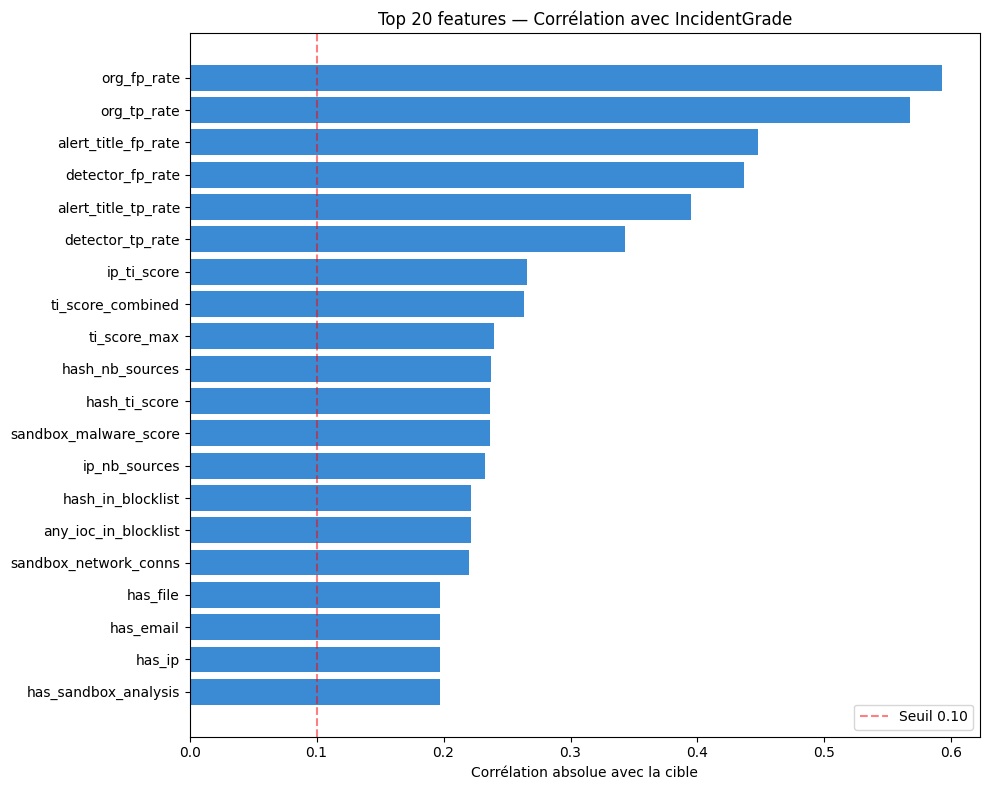


Top 5 features les plus corrélées à la cible :
org_fp_rate            0.593
org_tp_rate            0.567
alert_title_fp_rate    0.448
detector_fp_rate       0.437
alert_title_tp_rate    0.395
Name: target, dtype: float64


In [40]:
# S'assurer que toutes les colonnes object sont exclues des analyses numériques
string_cols = feat_ml.select_dtypes(include='object').columns.tolist()
if string_cols:
    print(f"[WARN] Colonnes string détectées et exclues : {string_cols}")
    feat_ml = feat_ml.drop(columns=string_cols)

feature_cols = [c for c in feat_ml.columns if c not in ['IncidentId', 'target']]

# Corrélation Pearson (relations linéaires)
corr_with_target = feat_ml[feature_cols + ['target']].corr()['target'].drop('target').abs()
corr_with_target = corr_with_target.sort_values(ascending=False)

# Mutual Information (relations non-linéaires) — complément indispensable
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    feat_ml[feature_cols].fillna(0),
    feat_ml['target'],
    random_state=RANDOM_SEED
)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

# Comparaison côte à côte
importance_df = pd.DataFrame({
    'pearson_corr': corr_with_target,
    'mutual_info':  mi_series
}).sort_values('mutual_info', ascending=False)

print("Top 10 features — Mutual Information vs Corrélation Pearson :")
print(importance_df.head(10).round(3))

# Features faibles selon les DEUX métriques — candidates à la suppression
weak = importance_df[(importance_df['pearson_corr'] < 0.02) & (importance_df['mutual_info'] < 0.01)]
if len(weak) > 0:
    print(f"\nFeatures faibles sur les deux métriques (à surveiller) : {weak.index.tolist()}")

fig, ax = plt.subplots(figsize=(10, 8))
top20 = corr_with_target.head(20)
bars = ax.barh(range(len(top20)), top20.values, color='#3B8BD4')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Corrélation absolue avec la cible')
ax.set_title('Top 20 features — Corrélation avec IncidentGrade')
ax.axvline(0.1, color='red', linestyle='--', alpha=0.5, label='Seuil 0.10')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\nTop 5 features les plus corrélées à la cible :')
print(corr_with_target.head(5).round(3))

In [41]:
# garder les features très peu corrélées (< 0.02) pour le ML, mais les signaler pour vigilance
weak_features = corr_with_target[corr_with_target < 0.02].index.tolist()
if weak_features:
    print(f'Features faiblement corrélées (< 0.02), à surveiller : {weak_features}')
    # On les garde quand même — le ML peut trouver des interactions non linéaires
    print('  → Conservées pour le ML (XGBoost gère bien les features faibles)')
else:
    print('Toutes les features ont une corrélation >= 0.02 ✓')

Features faiblement corrélées (< 0.02), à surveiller : ['hour_sin', 'org_nb_incidents', 'asset_internet_exposed', 'category_bp_rate', 'hour_of_day']
  → Conservées pour le ML (XGBoost gère bien les features faibles)


## 12. Sauvegarde

In [44]:
out_path = DATA_DIR / 'features_ml.csv'
# Sauvegarde CSV (compatibilité universelle)
out_path = DATA_DIR / 'features_ml.csv'
feat_ml.to_csv(out_path, index=False)

# Sauvegarde Parquet (plus rapide et compact, préserve les dtypes int8)
feat_ml.to_parquet(DATA_DIR / 'features_ml.parquet', index=False)

print(f'✅ features_ml.csv et features_ml.parquet sauvegardés : {feat_ml.shape[0]:,} incidents × {feat_ml.shape[1]} colonnes')
print(f'   Dont {len(feature_cols)} features ML + IncidentId + target')
print(f'\nRésumé des familles de features :')

families = {
    'Alerte brute (target encoding)': [
        'alert_title_tp_rate', 'alert_title_fp_rate', 'alert_title_bp_rate',
        'category_tp_rate', 'category_fp_rate', 'category_bp_rate',
        'nb_alerts', 'nb_evidences', 'nb_categories', 'nb_detectors',
    ],
    'Temporelle': [
        'hour_of_day', 'day_of_week', 'is_weekend', 'is_business_hours',
        'incident_duration_min', 'alert_rate_per_hour',
        'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    ],
    'Threat Intelligence': [
        'ip_ti_score', 'ip_in_blocklist', 'ip_nb_sources',
        'hash_ti_score', 'hash_in_blocklist', 'hash_nb_sources',
        'ti_score_max', 'ti_score_combined', 'any_ioc_in_blocklist',
    ],
    'CMDB / Asset': [
        'asset_criticality_score', 'asset_sensitivity_score',
        'asset_internet_exposed', 'asset_patch_risk', 'asset_risk_score',
    ],
    'Sandbox': [
        'sandbox_malware_score', 'sandbox_network_conns',
        'sandbox_process_injection', 'sandbox_c2_beaconing', 'has_sandbox_analysis',
    ],
    'Historique SOC': [
        'detector_tp_rate', 'detector_fp_rate', 'detector_bp_rate', 'detector_nb_incidents',
        'org_tp_rate', 'org_fp_rate', 'org_bp_rate', 'org_nb_incidents', 'OrgId',
    ],
    'Contexte incident': [
        'has_ip', 'has_file', 'has_account', 'has_email',
        'nb_entity_types', 'suspicion_level_encoded', 'has_threat_family', 'is_windows',
    ],
}

total = 0
for family, cols in families.items():
    present = [c for c in cols if c in feat_ml.columns]
    total += len(present)
    print(f'  {family}: {len(present)} features')
print(f'  TOTAL: {total} features')

# Sauvegarder les tables d'encodage pour les réutiliser en inférence
alert_title_stats.to_parquet(DATA_DIR / 'encoder_alert_title.parquet')
alert_title_stats.to_csv(DATA_DIR / 'encoder_alert_title.csv')

cat_stats.to_parquet(DATA_DIR / 'encoder_category.parquet')
cat_stats.to_csv(DATA_DIR / 'encoder_category.csv')

detector_stats_filtered.to_parquet(DATA_DIR / 'encoder_detector.parquet')
detector_stats_filtered.to_csv(DATA_DIR / 'encoder_detector.csv')

org_stats_filtered.to_parquet(DATA_DIR / 'encoder_org.parquet')
org_stats_filtered.to_csv(DATA_DIR / 'encoder_org.csv')

# Sauvegarder les taux globaux (fallback pour les nouvelles valeurs inconnues)
global_rates = {
    'global_tp_rate': global_tp_rate,
    'global_fp_rate': global_fp_rate,
    'global_bp_rate': global_bp_rate,
}
with open(DATA_DIR / 'global_rates.pkl', 'wb') as f:
    pickle.dump(global_rates, f)

# Version CSV des taux globaux pour la démo
pd.DataFrame([global_rates]).to_csv(DATA_DIR / 'global_rates.csv', index=False)

print("✅ Encodeurs sauvegardés en parquet et CSV pour l'inférence")

print('\n→ Prochaine étape : 03_ml_models.ipynb')

✅ features_ml.csv et features_ml.parquet sauvegardés : 30,000 incidents × 58 colonnes
   Dont 56 features ML + IncidentId + target

Résumé des familles de features :
  Alerte brute (target encoding): 10 features
  Temporelle: 10 features
  Threat Intelligence: 9 features
  CMDB / Asset: 5 features
  Sandbox: 5 features
  Historique SOC: 9 features
  Contexte incident: 8 features
  TOTAL: 56 features
✅ Encodeurs sauvegardés en parquet et CSV pour l'inférence

→ Prochaine étape : 03_ml_models.ipynb
